<a href="https://colab.research.google.com/github/Storm00212/SIGNALS-ASSIGNMENT-1/blob/main/QUESTION_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 4: Observation Windows and Spectral Limits

### Part a. Truncated Sinusoid: `x(t) = cos(2πf0t)`


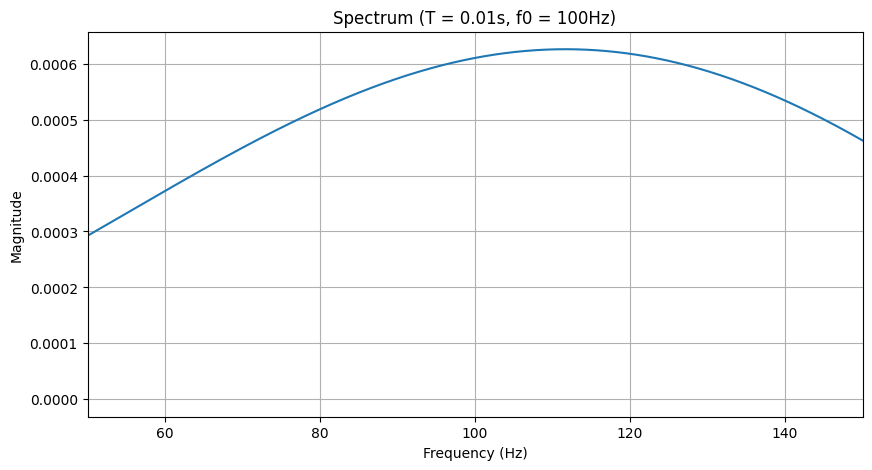

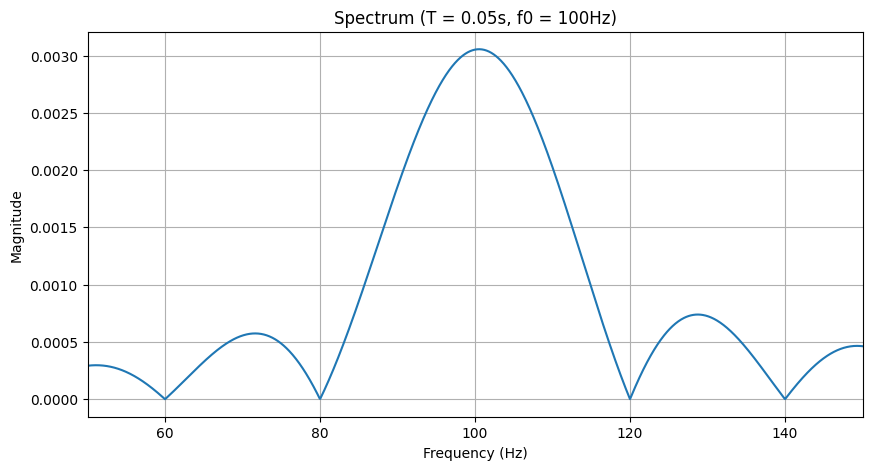

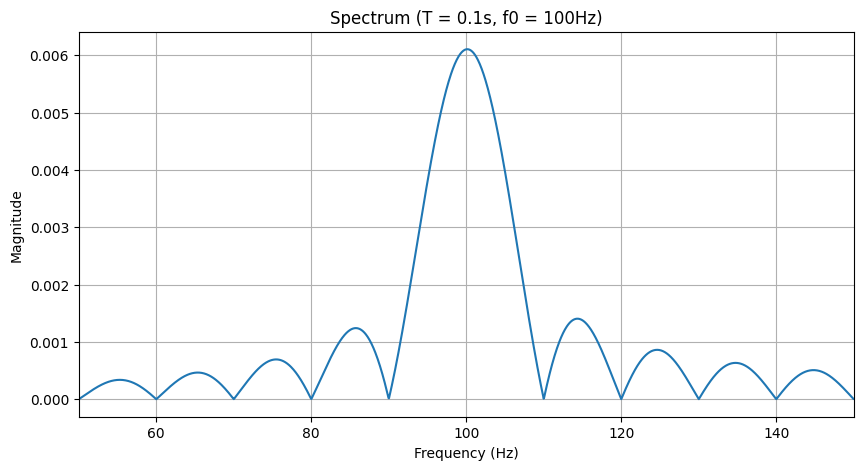

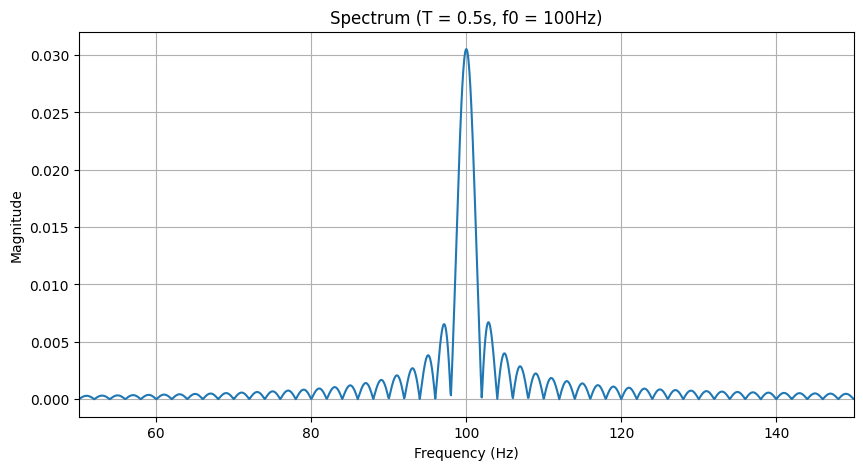

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# parameters
f0 = 100  # frequency
fs = 1000 # samples

T_windows = [0.01, 0.05, 0.1, 0.5]  # time lengths
Nfft = 2**14 # FFT size, pad with zeros for smooth freq stuff

# for each window length
for T in T_windows:
    t = np.arange(0, T, 1/fs) # time array for this window. nikama np.linspace but instead of no of samples inaeka sampling rate
    x_t = np.cos(2 * np.pi * f0 * t) # the signal

    # zero-pad signal for FFT
    x_padded = np.pad(x_t, (0, Nfft - len(x_t)), 'constant')# for adding zeroes

    # do FFT
    X_f = fft(x_padded)
    frequencies = fftfreq(Nfft, 1/fs)

    # plot spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(frequencies[:Nfft//2], 2/Nfft * np.abs(X_f[:Nfft//2]))
    plt.title(f'Spectrum (T = {T}s, f0 = {f0}Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(f0 - 50, f0 + 50)
    plt.grid(True)
    plt.show()

    #so this kind of has a zoom out effect when you think abt it


### Part b. Contrast: Rectangular vs. Hamming Window

Okay, so comparing windows. Rectangular vs. Hamming. What's the difference in spectrum? Let's see how they affect the main peak and those annoying sidelobes.

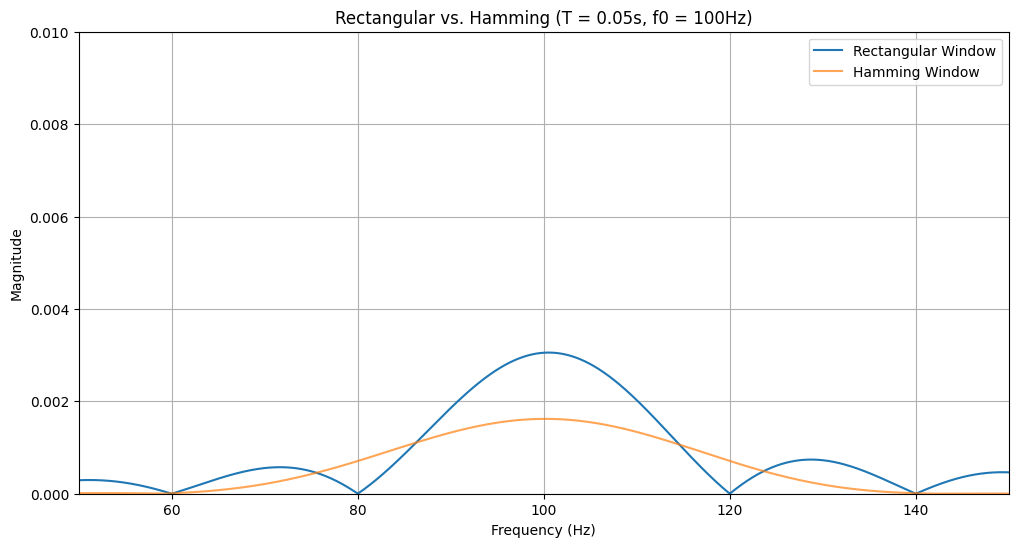

Observations:
Rectangular Window: super narrow main peak, but bigger sidelobes. Good for exact freq, but noisy.
Hamming Window: main peak a bit wider, but sidelobes way smaller. Less noise, smoother. Trade-off, man.


In [10]:
import numpy as np
import matplotlib.pyplot as plt # Added this import to ensure plt is always available
from scipy.fft import fft, fftfreq
from scipy.signal.windows import hamming # need hamming window from scipy

# params for comparison
T_compare = 0.05  # just pick one window length

# signal again
t_compare = np.arange(0, T_compare, 1/fs)
x_t_compare = np.cos(2 * np.pi * f0 * t_compare)

# Rectangular Window (default)
# basically no window, just the signal
rect_window = np.ones(len(x_t_compare)) # inaunda u(t)
x_rect = x_t_compare * rect_window
x_rect_padded = np.pad(x_rect, (0, Nfft - len(x_rect)), 'constant') #padded ka vile swali inasema
X_rect_f = fft(x_rect_padded)

# Hamming Window
# smoother window, tapers ends, less noise
hamming_window = hamming(len(x_t_compare))
x_ham = x_t_compare * hamming_window
x_ham_padded = np.pad(x_ham, (0, Nfft - len(x_ham)), 'constant')
X_ham_f = fft(x_ham_padded)

# Recalculate frequencies for this cell's context
frequencies = fftfreq(Nfft, 1/fs)

# plot comparison
plt.figure(figsize=(12, 6))
plt.plot(frequencies[:Nfft//2], 2/Nfft * np.abs(X_rect_f[:Nfft//2]), label='Rectangular Window')
plt.plot(frequencies[:Nfft//2], 2/Nfft * np.abs(X_ham_f[:Nfft//2]), label='Hamming Window', alpha=0.7)
plt.title(f'Rectangular vs. Hamming (T = {T_compare}s, f0 = {f0}Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(f0 - 50, f0 + 50)
plt.ylim(0, 0.01) # Adjusted y-axis limit to make peaks visible
plt.grid(True)
plt.legend()
plt.show()

print("Observations:")
print("Rectangular Window: super narrow main peak, but bigger sidelobes. Good for exact freq, but noisy.")
print("Hamming Window: main peak a bit wider, but sidelobes way smaller. Less noise, smoother. Trade-off, man.")

### Part c. Truncated Pulse: From Time to Freq

Now, a simple square pulse. What happens when we watch it for different times? Whole pulse, or just part? This changes everything in frequency.

#### Analytical Transform (The Math Part)

Pulse in time = sinc in frequency. `P(f) = τ * sinc(πfτ)`. Truncating it means we're multiplying by a window, which messes up the sinc a bit in frequency. It's complex, but observing changes how the sinc looks.

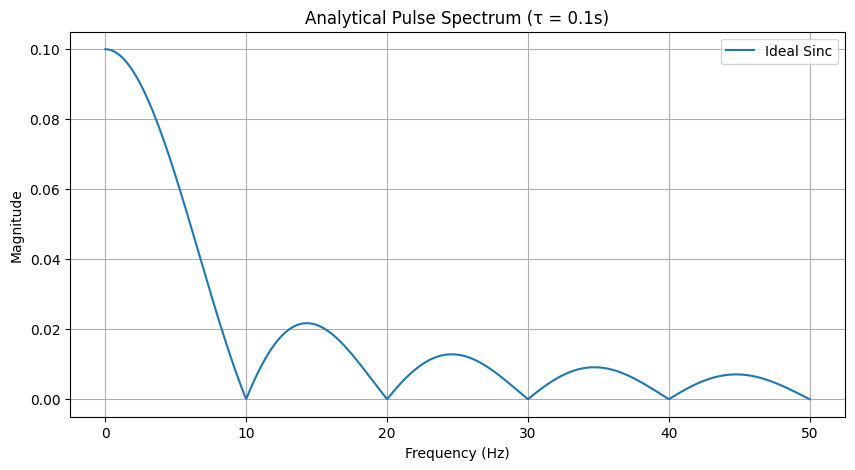

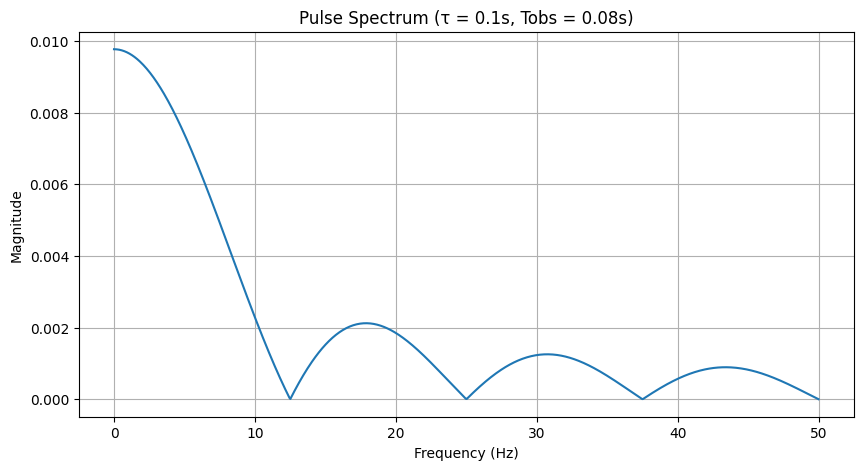


Yo, Tobs = 0.08s:
Obs window shorter than pulse. Spectrum gets messy, broadened. Losing info about the pulse.


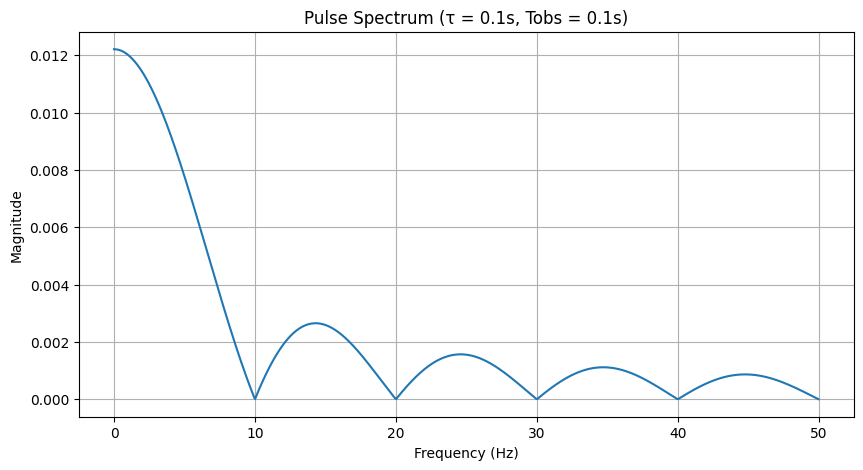


No cap, Tobs = 0.1s:
Obs window matches pulse. This is the good stuff, most accurate spectrum.


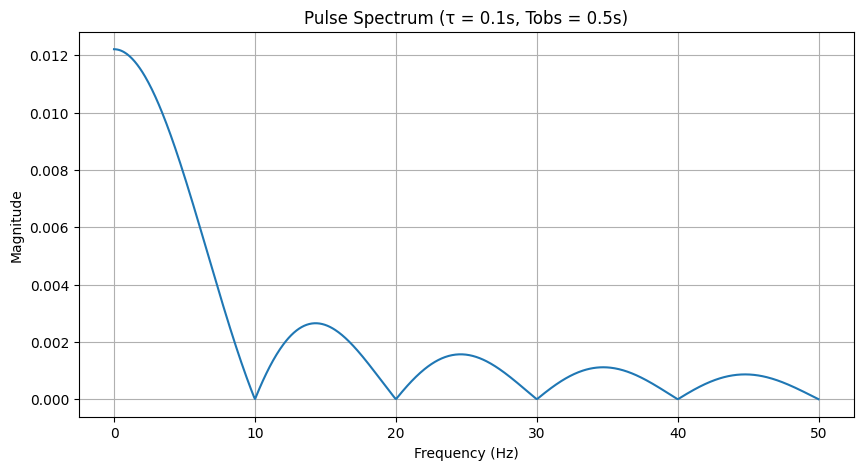


Bet, Tobs = 0.5s:
Obs window longer than pulse. Full pulse, plus zeros. Spectrum denser, better freq resolution, but still the sinc shape.


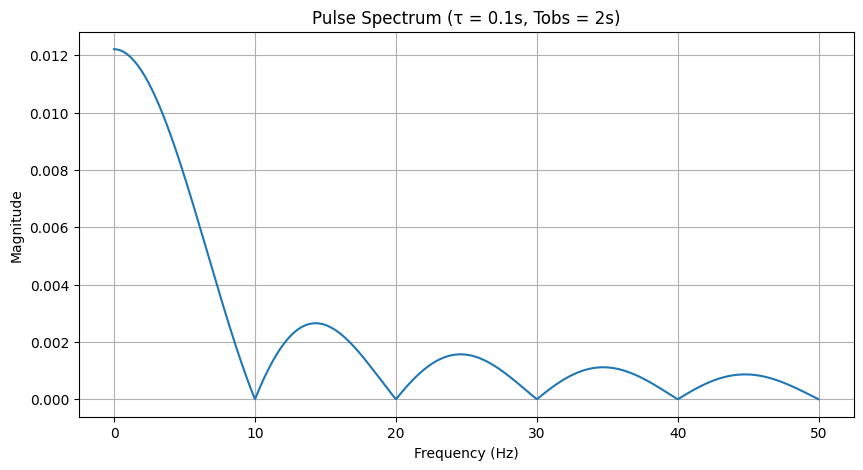


Bet, Tobs = 2s:
Obs window longer than pulse. Full pulse, plus zeros. Spectrum denser, better freq resolution, but still the sinc shape.


In [7]:
# hapa basically tunaangalia vile observation window inavary na tao.
# parameters
tau = 0.1  # pulse duration
Tobs_windows = [0.08, 0.1, 0.5, 2] # observation times

# Analytical Plot (for ideal sinc reference)
analytic_freq = np.linspace(0, 50, 1000)
analytic_sinc = tau * np.sinc(analytic_freq * tau)

plt.figure(figsize=(10, 5))
plt.plot(analytic_freq, np.abs(analytic_sinc), label='Ideal Sinc')
plt.title('Analytical Pulse Spectrum (τ = 0.1s)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend()
plt.show()

# for each observation window
for Tobs in Tobs_windows:
    t_obs = np.arange(-Tobs/2, Tobs/2, 1/fs) # time axis for window

    # create the pulse (1 if within tau, 0 otherwise)
    pulse_t = np.where((t_obs >= -tau/2) & (t_obs <= tau/2), 1, 0)

    # zero-pad for FFT
    pulse_padded = np.pad(pulse_t, (0, Nfft - len(pulse_t)), 'constant')

    # do FFT
    Pulse_f = fft(pulse_padded)
    frequencies_pulse = fftfreq(Nfft, 1/fs)

    # plot magnitude spectrum (0-50 Hz)
    plt.figure(figsize=(10, 5))
    mask = (frequencies_pulse >= 0) & (frequencies_pulse <= 50)
    plt.plot(frequencies_pulse[mask], 2/Nfft * np.abs(Pulse_f[mask]))
    plt.title(f'Pulse Spectrum (τ = {tau}s, Tobs = {Tobs}s)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.show()

    # physical consequences (what it means)
    if Tobs < tau:
        print(f"\nTobs = {Tobs}s:")
        print("Obs window shorter than pulse. Spectrum gets messy, broadened. Losing info about the pulse.")
    elif Tobs == tau:
        print(f"\n Tobs = {Tobs}s:")
        print("Obs window matches pulse. This is the good stuff, most accurate spectrum.")
    else: # Tobs > tau
        print(f"\nTobs = {Tobs}s:")
        print("Obs window longer than pulse. Full pulse, plus zeros. Spectrum denser, better freq resolution, but still the sinc shape.")
